**Importing all the required libraries**

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Reading the file**

In [218]:
!pip install gdown # reading file from g-drive
import gdown


In [219]:
!gdown --fuzzy "https://drive.google.com/file/d/1vb2EFO8xt3tJ8t638TuwI_bv8mNid3na/view?usp=sharing"



Downloading...
From: https://drive.google.com/uc?id=1vb2EFO8xt3tJ8t638TuwI_bv8mNid3na
To: /content/penguins_size.csv
100% 13.9k/13.9k [00:00<00:00, 20.5MB/s]


In [220]:
df = pd.read_csv("penguins_size.csv")

**Data Audit & Availability Check**

In [221]:
df.head() # returns the first five rows of the dataset

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [222]:
print(df.shape) # checking numbers of rows and columns in a dataframe

(344, 7)


In [223]:
print(df.info()) # summary of the structure and content of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [224]:
df.describe().T # gives descriptive statistics of the DataFrame

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [225]:
df.describe(include=['object']).T # gives descriptive statistics of the columns having object datatype in DataFrame

,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,334,3,MALE,168


**Data Cleaning (Handling Missing Values)**

In [226]:
df = df[~(df['sex'] == '.')] # removing rows unwanted values for sex column

In [227]:
print(df.isnull().sum()) # checking for null values

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


In [228]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols = ['island', 'sex']

# Filling numeric missing values with mean
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


**Exploratory Data Analysis**

In [229]:
pd.crosstab(df['sex'], df['species'])

species,Adelie,Chinstrap,Gentoo
sex,,,
FEMALE,73,34,58
MALE,79,34,65


<Axes: xlabel='sex'>

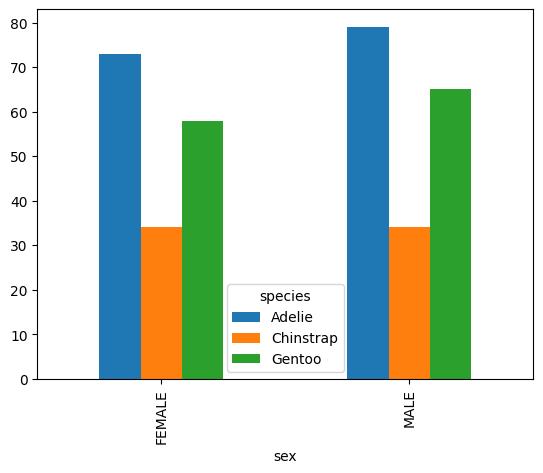

In [230]:
pd.crosstab(df['sex'], df['species']).plot(kind='bar')

In [231]:
pd.crosstab(df['island'], df['species'])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,52,0,0


<Axes: xlabel='island'>

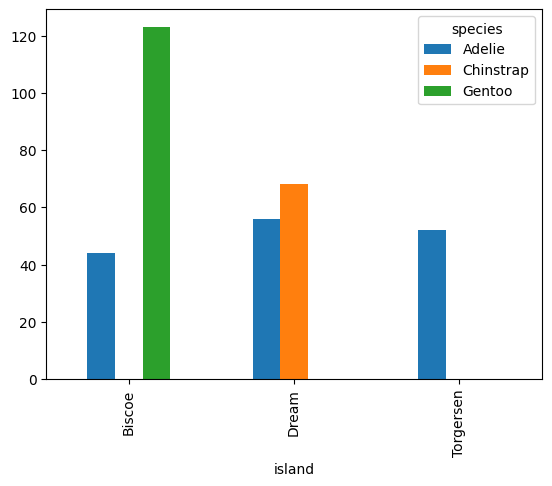

In [232]:
pd.crosstab(df['island'], df['species']).plot(kind='bar')

In [233]:
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols = ['island', 'sex']

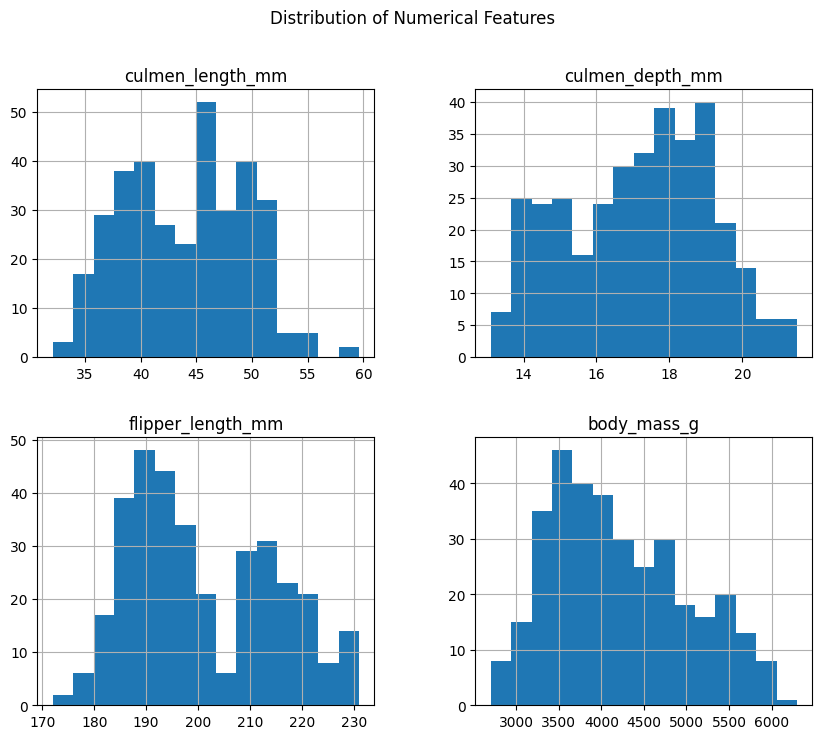

In [234]:
# this will give the distribution of numerical features such as culmen length, depth, flipper length, and body mass
# Whether the values are normally distributed or skewed

df[num_cols].hist(figsize=(10, 8), bins=15)
plt.suptitle("Distribution of Numerical Features")
plt.show()

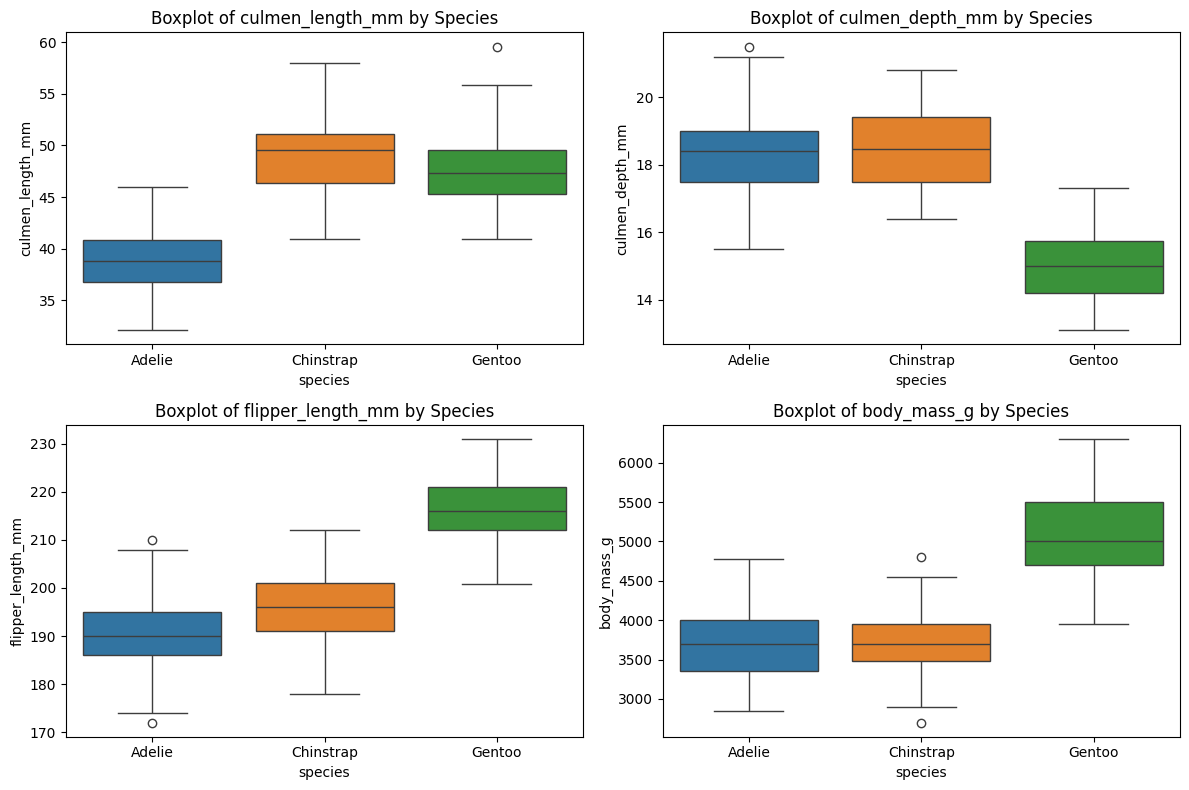

In [235]:
# Boxplots to compare feature variation across species
# Which species tends to have larger/smaller body parts

plt.figure(figsize=(12, 8))
for i, col in enumerate(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='species', y=col, hue='species', legend=False)
    plt.title(f'Boxplot of {col} by Species')
plt.tight_layout()
plt.show()

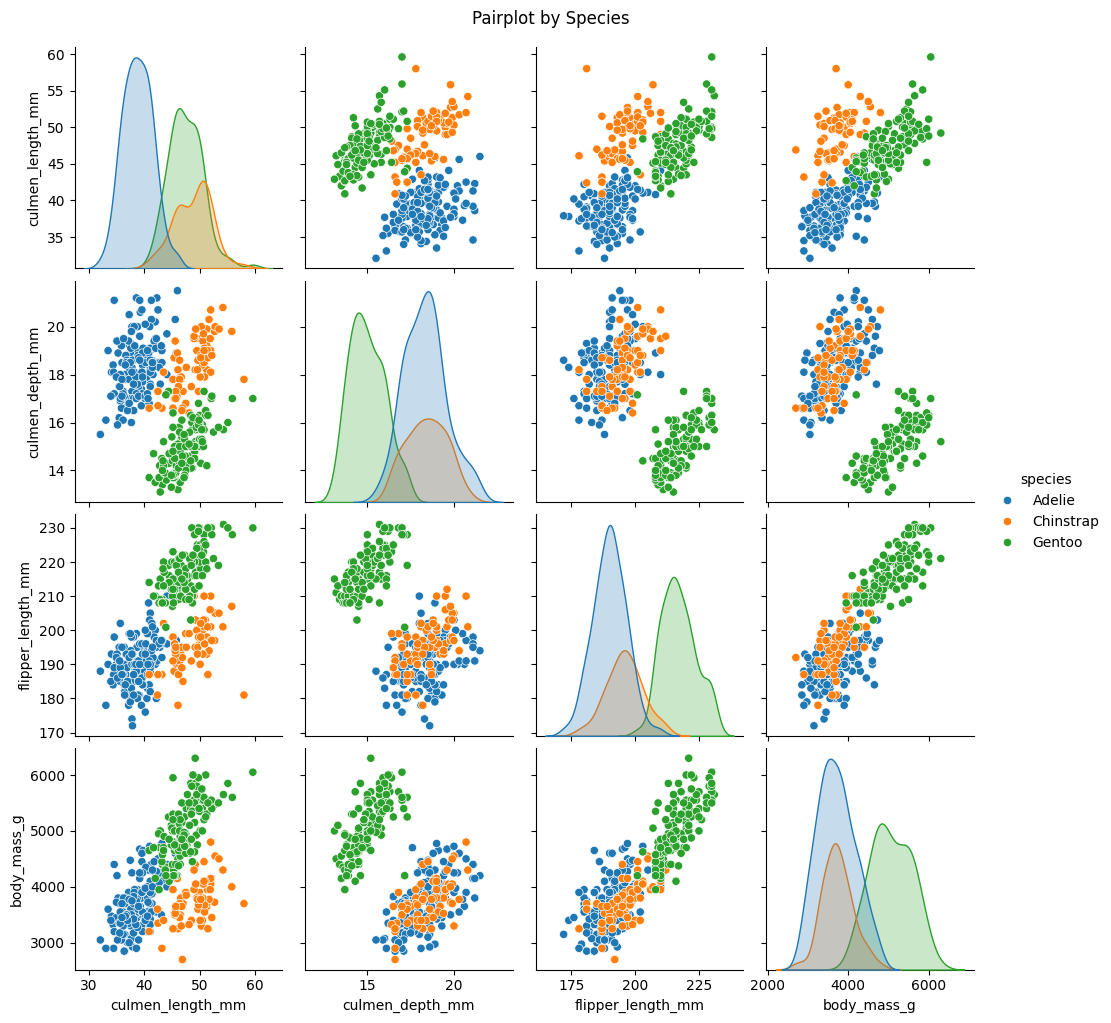

In [236]:
# Pairplot colored by species - To check how species differ across multiple feature combinations
# Which features form natural separations between species

sns.pairplot(df, hue='species', vars=num_cols)
plt.suptitle("Pairplot by Species", y=1.02)
plt.show()

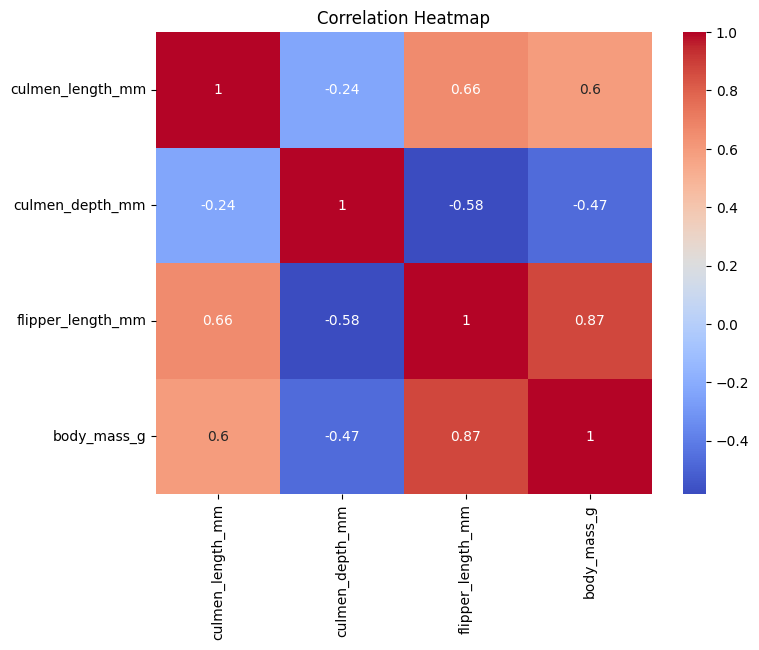

In [237]:
# Correlation heatmap - To measure relationships between features
# Which measurements are strongly related and which features provide unique information

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Time series is not needed because we don't have any colum as date/time in our dataset

**Label encoding**

In [238]:
# To transforms categorical values into numerical representations by assigning a unique integer to each distinct category.
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

**Feature Creation**

In [239]:
# Such ratios can capture shape information that raw lengths/depths don’t
df['bill_ratio'] = df['culmen_length_mm'] / df['culmen_depth_mm']

I created bill_ratio to represent beak shape. I tested cluster quality with and without this feature using Silhouette Score — the score improved, showing that the engineered feature contributes to clearer cluster separation.

**Feature Selection**

In [240]:
# Preparing Data for Clustering
# X is the matrix of features to be feeded into K-Means. It excludes species (the true label) because clustering is unsupervised.
X = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
        'body_mass_g', 'bill_ratio']]

# Scale the features
# K-Means uses Euclidean distances so unscaled features with larger magnitudes can dominate. Scaling puts all features on a comparable scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensionality Reduction and Feature Evaluation are not mandatory for this dataset because the number of features is small. However, evaluating the engineered feature using Silhouette Score proves that the new feature improves cluster separation. So we included these steps to make the clustering model more interpretable and to justify our feature engineering choice

**Feature Evaluation**

In [241]:
# Without bill_ratio
X_no_ratio = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']]
X_no_ratio_scaled = scaler.fit_transform(X_no_ratio)
kmeans_no_ratio = KMeans(n_clusters=3, random_state=42) # took K=3 cause there are three species so we are expecting 3 clusters
labels_no_ratio = kmeans_no_ratio.fit_predict(X_no_ratio_scaled)
sil_no_ratio = silhouette_score(X_no_ratio_scaled, labels_no_ratio)

# With bill_ratio
X_with_ratio = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
                   'body_mass_g', 'bill_ratio']]
X_with_ratio_scaled = scaler.fit_transform(X_with_ratio)
kmeans_with_ratio = KMeans(n_clusters=3, random_state=42)
labels_with_ratio = kmeans_with_ratio.fit_predict(X_with_ratio_scaled)
sil_with_ratio = silhouette_score(X_with_ratio_scaled, labels_with_ratio)

print("\nSilhouette Score WITHOUT bill_ratio:", sil_no_ratio)
print("Silhouette Score WITH bill_ratio:", sil_with_ratio)


Silhouette Score WITHOUT bill_ratio: 0.443291614574143
Silhouette Score WITH bill_ratio: 0.4729025827285935


Clustering

In [242]:
# Determine Optimal Number of Clusters (k)
inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

Elbow Method helps identify the optimal k by showing where adding more clusters stops improving the model significantly.

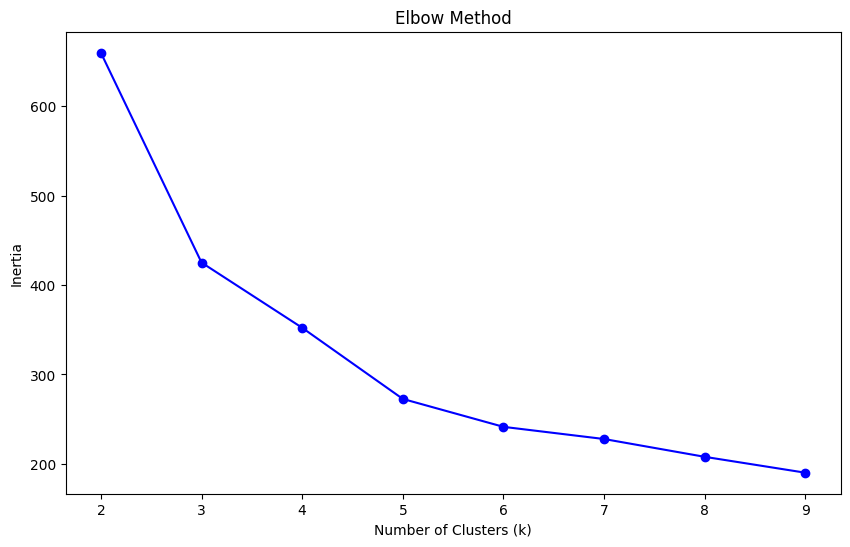

In [243]:
# Elbow Method
plt.figure(figsize=(10,6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Silhouette Score evaluates the quality of clustering by measuring how well each point fits into its assigned cluster.

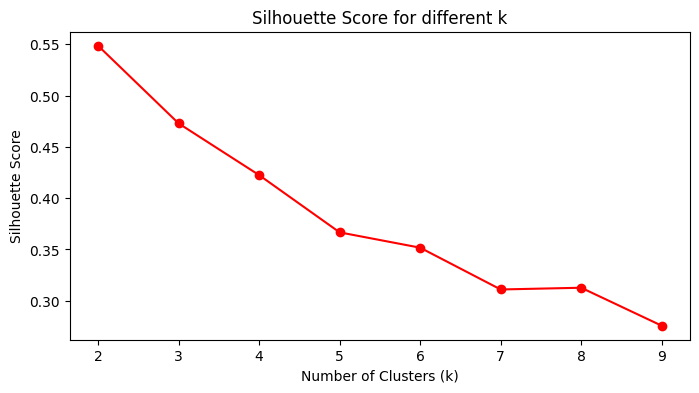

In [244]:
# Silhouette Score
plt.figure(figsize=(8,4))
plt.plot(K, silhouette, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for different k')
plt.show()

Even though elbow and silhouette suggested highest scores at k =2, we chose k = 3 because it aligns with the real-world biological groups in the dataset. If we choose k=2 two species that are similar will probably get merged into the same cluster.This causes large overlap because K-Means is trying to fit 3 natural groups into 2 forced groups.So, we went with the next k values i.e 3 at which the scores are 2nd highest.

Model Training

In [245]:
# Apply K-Means with chosen k
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [246]:
# Compare Clusters with Actual Species
print("\n--- Cluster vs Species Crosstab ---")
print(pd.crosstab(df['species'], df['cluster']))


--- Cluster vs Species Crosstab ---
cluster      0    1   2
species                
Adelie     144    0   8
Chinstrap    5    0  63
Gentoo       0  122   1


Model Interpretation

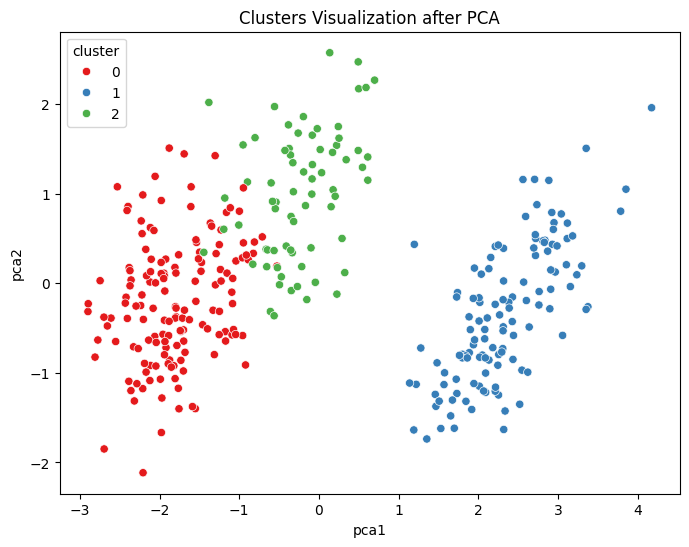

In [247]:
# Visualize Clusters using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['pca1'], df['pca2'] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set1')
plt.title("Clusters Visualization after PCA")
plt.show()

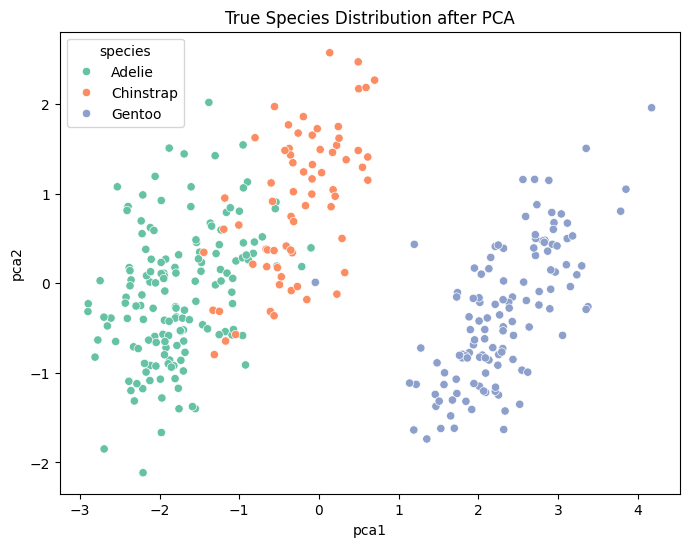

In [248]:
# True Species Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='species', palette='Set2')
plt.title("True Species Distribution after PCA")
plt.show()

In [249]:
from google.colab import files

df.to_csv("penguins_final_output.csv", index=False)
files.download("penguins_final_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>